# DL062 离散扩散与去噪学习

时间离散、状态连续。此Notebook在新内核顺序执行，真实训练三种子DDPM。训练与采样严格区分；输出写入notebook_outputs，不覆盖教材固定结果。

In [1]:
from pathlib import Path
import sys, json, numpy as np, torch
import experiment as e
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=130, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'unit':Path.cwd().name})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '062'}


## 1 检查索引与日程
数组长度T+1，索引0表示干净端点；训练与反向预测只用1到T。β是方差，采样必须乘平方根。

In [2]:
s=e.schedule()
print('T:',s['T'],'length:',len(s['beta']))
print('beta_0, alpha_bar_0:',s['beta'][0].item(),s['abar'][0].item())
print('alpha_bar_T:',s['abar'][-1].item(),'posterior_var_1:',s['posterior_var'][1].item())

T: 200 length: 201
beta_0, alpha_bar_0: 0.0 1.0
alpha_bar_T: 0.006121965125203133 posterior_var_1: 0.0


## 2 手算两步前向与后验
β1=0.1、β2=0.2。x0=2时，x2均值为2√0.72，方差0.28；已知x2=1时，上一步后验方差约0.07143。

In [3]:
toy=e.schedule(2,.1,.2)
x0=torch.full((1,2),2.)
print('forward sample epsilon=-1:',e.q_sample(x0,torch.tensor([2]),-torch.ones_like(x0),toy))
print('posterior mean for x2=1:',e.posterior_mean(torch.ones_like(x0),x0,torch.tensor([2]),toy))
print('posterior variance:',toy['posterior_var'][2].item())

forward sample epsilon=-1: tensor([[1.1679, 1.1679]])
posterior mean for x2=1: tensor([[1.6747, 1.6747]])
posterior variance: 0.071428582072258


## 3 公式与边界测试
比较闭式/链式矩、后验两种表达、KL权重、t=0恒等、t=1分支与完整反向时间序列。

In [4]:
import unittest,test_experiment
result=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not result.wasSuccessful(): raise RuntimeError('unit tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 18 tests in 0.452s

OK


## 4 数据与前向边缘
每幅图是给定时间的边缘抽样，不声称四幅图构成同一条逐步前向链。

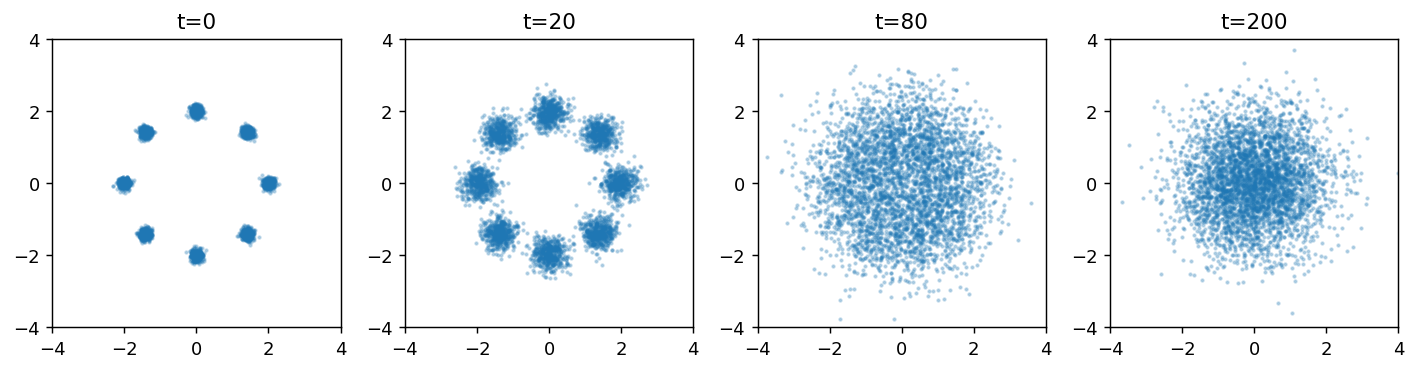

In [5]:
import matplotlib.pyplot as plt
x,_=e.make_data();tx=torch.from_numpy(x)
fig,axes=plt.subplots(1,4,figsize=(11,3))
for ax,t in zip(axes,[0,20,80,200]):
    noisy=e.q_sample(tx,torch.full((len(tx),),t,dtype=torch.long),torch.randn_like(tx),s).numpy()
    ax.scatter(noisy[:,0],noisy[:,1],s=2,alpha=.25)
    ax.set(title=f't={t}',xlim=(-4,4),ylim=(-4,4),aspect='equal')
fig.tight_layout();show(fig);plt.close(fig)

## 5 实际训练三种子
每个7000次Adam更新。训练t均匀抽样，目标为按坐标平均的无权重噪声MSE，不是精确似然。

In [6]:
results=e.main(Path('notebook_outputs'),steps=7000)
for row in results['runs']:
    print(row['seed'],row['final'],row['history'][-1])

11 {'coverage': 8, 'valid_fraction': 0.984619140625, 'counts': [513, 441, 479, 500, 543, 509, 504, 544], 'conditional_max_mass': 0.1348871807587404, 'mean_nearest_distance': 0.12261636555194855} {'step': 7000, 'train_mse': 0.3139432668685913, 'validation_mse': 0.2908857762813568}


23 {'coverage': 8, 'valid_fraction': 0.9833984375, 'counts': [669, 455, 390, 338, 507, 494, 528, 647], 'conditional_max_mass': 0.16608738828202582, 'mean_nearest_distance': 0.12393128871917725} {'step': 7000, 'train_mse': 0.3148004710674286, 'validation_mse': 0.2986595630645752}


37 {'coverage': 8, 'valid_fraction': 0.99267578125, 'counts': [504, 574, 481, 416, 473, 602, 522, 494], 'conditional_max_mass': 0.14805705853418594, 'mean_nearest_distance': 0.11113391816616058} {'step': 7000, 'train_mse': 0.3129713535308838, 'validation_mse': 0.2868298292160034}


11 {'coverage': 8, 'valid_fraction': 0.984619140625, 'counts': [513, 441, 479, 500, 543, 509, 504, 544], 'conditional_max_mass': 0.1348871807587404, 'mean_nearest_distance': 0.12261636555194855} {'step': 7000, 'train_mse': 0.3139432668685913, 'validation_mse': 0.2908857762813568}
23 {'coverage': 8, 'valid_fraction': 0.9833984375, 'counts': [669, 455, 390, 338, 507, 494, 528, 647], 'conditional_max_mass': 0.16608738828202582, 'mean_nearest_distance': 0.12393128871917725} {'step': 7000, 'train_mse': 0.3148004710674286, 'validation_mse': 0.2986595630645752}
37 {'coverage': 8, 'valid_fraction': 0.99267578125, 'counts': [504, 574, 481, 416, 473, 602, 522, 494], 'conditional_max_mass': 0.14805705853418594, 'mean_nearest_distance': 0.11113391816616058} {'step': 7000, 'train_mse': 0.3129713535308838, 'validation_mse': 0.2868298292160034}


## 6 从纯噪声生成并看完整链
采样不访问x0；以下中间状态来自同一批反向链。

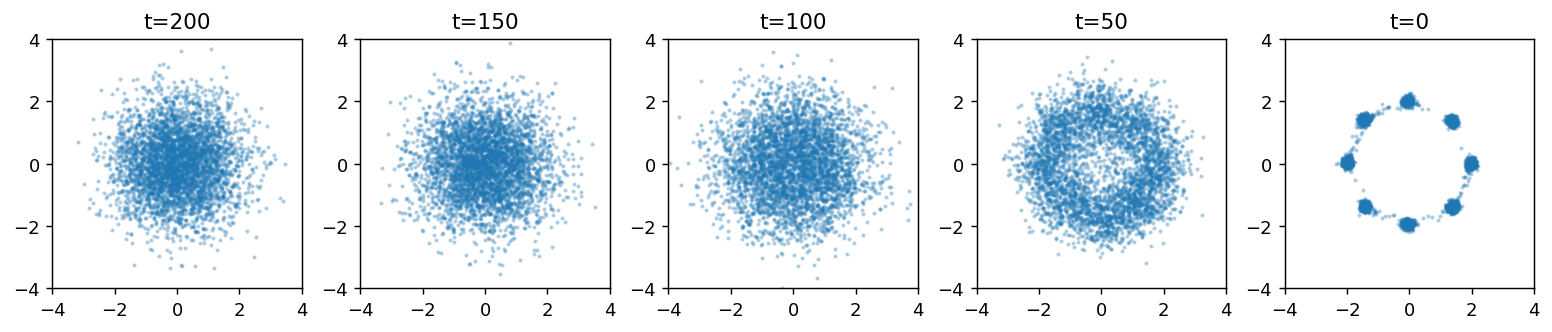

In [7]:
f=np.load('notebook_outputs/ddpm_seed11_samples.npz')
fig,axes=plt.subplots(1,5,figsize=(12,3))
for ax,t in zip(axes,[200,150,100,50,0]):
    a=f['path_'+str(t)]
    ax.scatter(a[:,0],a[:,1],s=2,alpha=.25)
    ax.set(title=f't={t}',xlim=(-4,4),ylim=(-4,4),aspect='equal')
fig.tight_layout();show(fig);plt.close(fig)

## 7 端点密度与展示采样
默认t=1输出均值；terminal_noise=True才从正方差β1的连续高斯端点抽样。两种输出都保存并分别评价。

In [8]:
for row in results['runs']:
    print('seed',row['seed'],'mean endpoint',row['final']['valid_fraction'],'Gaussian endpoint',row['terminal_gaussian_sample']['valid_fraction'])
print('time bins:',results['runs'][0]['time_bins'])
print('zero baseline:',results['runs'][0]['zero_predictor_validation_mse'])

seed 11 mean endpoint 0.984619140625 Gaussian endpoint 0.984130859375
seed 23 mean endpoint 0.9833984375 Gaussian endpoint 0.984130859375
seed 37 mean endpoint 0.99267578125 Gaussian endpoint 0.9931640625
time bins: [{'t_start': 1, 't_end': 20, 'n': 195, 'mse': 0.41940760612487793}, {'t_start': 21, 't_end': 60, 'n': 416, 'mse': 0.40810760855674744}, {'t_start': 61, 't_end': 120, 'n': 584, 'mse': 0.45406314730644226}, {'t_start': 121, 't_end': 200, 'n': 853, 'mse': 0.0926188975572586}]
zero baseline: 0.9801324605941772


## 8 结论检查
请解释：给定x0的后验高斯为何不代表边缘反向分布必为高斯？无权重MSE为何不能直接叫精确似然？为什么终点barαT非零仍可从标准正态近似采样？不要把二维结果外推为图像基准结论。